# Week 9 - Combining Models (solution)


Learning contents:
- Base Classifier
    - Train a Least Squares classifier, perform a prediction on the samples, and compute the accuracy
    - Plot the decision boundary for least squares classifier
- Committees
    - Split the training data into M=9 equally sized, non-overlapping parts
    - Train M=9 Least Squares classifiers, one for each data split
    - Perform predictions on the whole dataset using a comitteee of classifiers and compute the accuracy
    - Plot the decision boundary for committee classifier
- Decision tree
    - Fit a DecisionTreeClassifier using scikit-learn, perform a prediction on the data, and compute the accuracy
    - Plot the decision boundary for the DecisionTreeClassifier
- AdaBoost
    - Create an AdaBoost classifier of DecisionTreeClassifiers using the scikit-learn library
    - Plot the decision boundary for the AdaBoostClassifier


In [17]:
# Dependencies
import numpy as np
import scipy
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set(); sns.set_palette('bright')

In [18]:
# Some plotting functions, we'll be using later


def plot_scatter(data, target, alpha=0.5, legend=True):
    scatter = plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=alpha, cmap='rainbow')
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    
def plot_mesh(X, pred_fn, n_class=2):
    plt_margin = 5
    x_min, x_max = min(X[:,0]) - plt_margin, max(X[:,0]) + plt_margin
    y_min, y_max = min(X[:,1]) - plt_margin, max(X[:,1]) + plt_margin
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = pred_fn(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))

# Dataset
We'll be working with a slightly modified version of the digits data

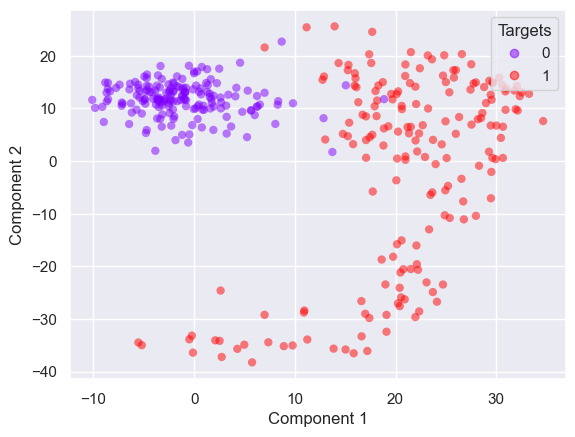

In [19]:
digits = load_digits(n_class=2)

# Get a 2D version of the data using PCA
pca = PCA(n_components=2)
t = digits.target
X = pca.fit_transform(digits.data)

# In order to get a non-linearly seperable case, 
# we'll modify the data a bit this time, 
# translating the '-1' class to the right and up
X = np.where(
    np.repeat(np.expand_dims(t == 1, axis=1), 2, axis=1), 
    X, 
    np.vstack([X[:,0]+20, X[:,1]+10]).T
)

N = len(t) # total number of samples

plot_scatter(X, t)

# 0) Base Classifier

## 0.1) Train a Least Squares classifier, perform a prediction on the samples, and compute the accuracy
You should have the solution for this from the exercise "Week 7 - Linear classification".

In [20]:
class LeastSquaresClassifier():
    @staticmethod
    def phi(X):
        """ Augment with bias component: phi_0(x) = 1 """
        return np.hstack((np.ones((len(X),1)), X))

    def fit(self, X, y, sample_weights=None):
        X_tilde = self.phi(X)
        W_tilde = np.linalg.pinv(X_tilde) @ y
        W_tilde = np.expand_dims(W_tilde,axis=0)
        self.W = W_tilde
        return self # allows chaining of operations

    def predict(self, X):
        X_tilde = self.phi(X)
        y = (self.W @ X_tilde.T)[0]
        return y

def accuracy(preds, targets):
    return np.sum(preds == targets) / len(targets)
    
lsq_classifier = LeastSquaresClassifier().fit(X,t)
preds = lsq_classifier.predict(X) > 0.5
accuracy(preds, t)

np.float64(0.9694444444444444)

## 0.2) Plot the decision boundary for least squares classifier

/var/folders/w8/4ydrws9n16d44w_rm7l3kbtx_94klw/T/ipykernel_15697/593679599.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = plt.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


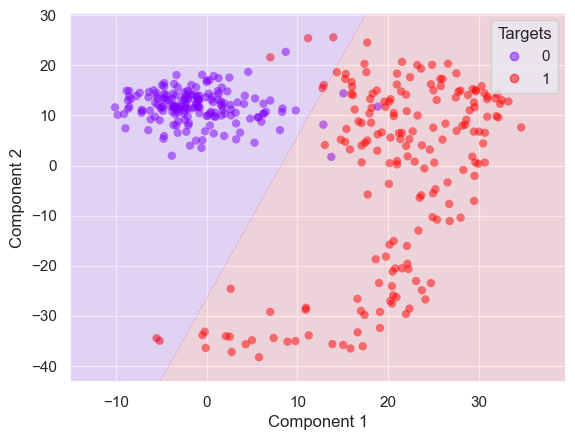

In [21]:
plot_scatter(X, t)
plot_mesh(X, lambda x: lsq_classifier.predict(x) > 0.5)

# 1) Committees

## 1.1) Split the training data into M=9 equally sized, non-overlapping parts

In [22]:
M = 9
X_split = np.split(X, M)
t_split = np.split(t, M)

## 1.2) Train M=9 Least Squares classifiers, one for each data split

In [23]:
lsq_classifiers = [
    LeastSquaresClassifier().fit(X_partial, t_partial) 
    for X_partial, t_partial in zip(X_split, t_split)
]

## 1.3) Perform a prediction on the whole dataset using comitteee of classifiers and compute the accuracy

In [24]:
def predict_committee(X, classifiers):
    ys = [classifier.predict(X) > 0.5 for classifier in classifiers]
    y_com = np.mean(ys, axis=0)
    return y_com

preds_com = predict_committee(X, lsq_classifiers) > 0.5
accuracy(preds_com, t)

np.float64(0.9583333333333334)

## 1.4 Plot the decision boundary for committee classifier

/var/folders/w8/4ydrws9n16d44w_rm7l3kbtx_94klw/T/ipykernel_15697/593679599.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = plt.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


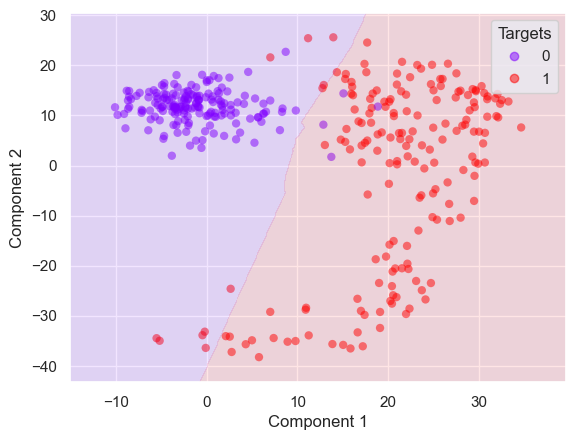

In [25]:
plot_scatter(X, t)
plot_mesh(X, lambda x: predict_committee(x, lsq_classifiers) > 0.5)

# 2) Tree

## 2.1) Fit a DecisionTreeClassifier using `scikit-learn`, perform a prediction on the data, and compute the accuracy
Use a `max_depth=3`

In [26]:
from sklearn.tree import DecisionTreeClassifier

tree_classifier = DecisionTreeClassifier(max_depth=3)
tree_classifier.fit(X,t)
preds_tree = tree_classifier.predict(X)
accuracy(preds_tree, t)

np.float64(0.9861111111111112)

## 2.2) Plot the decision boundary for the DecisionTreeClassifier

/var/folders/w8/4ydrws9n16d44w_rm7l3kbtx_94klw/T/ipykernel_15697/593679599.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = plt.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


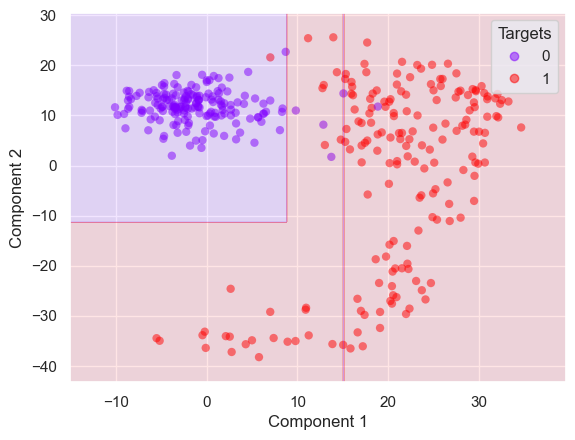

In [27]:
plot_scatter(X, t)
plot_mesh(X, lambda x: tree_classifier.predict(x))

# 3) AdaBoost

## 3.1) Create an AdaBoost classifier of DecisionTreeClassifiers using the `scikit-learn` library
Use a depth of 1 for the `DecisionTreeClassifier` and 7 estimators for the `AdaBoostClassifier`. Use the defaults for the other parameters

In [28]:
from sklearn.ensemble import AdaBoostClassifier

ab_classifier = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),
    n_estimators=7
)
ab_classifier.fit(X, t)

preds_ab = ab_classifier.predict(X)
accuracy(preds_ab, t)

np.float64(0.9777777777777777)

## 3.2) Plot the decision boundary for the AdaBoostClassifier

/var/folders/w8/4ydrws9n16d44w_rm7l3kbtx_94klw/T/ipykernel_15697/593679599.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = plt.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


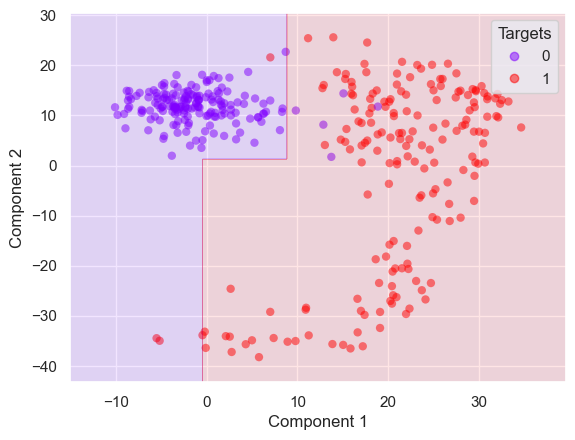

In [29]:
plot_scatter(X, t)
plot_mesh(X, lambda x: ab_classifier.predict(x))